In [1]:
import pandas as pd
import numpy as np
 
data = pd.read_csv('ADITI_CLASS_NOONDATA.csv') 
data.drop(21335, axis = 0, inplace = True)   # Unwanted time coming  486-90030  in steaming time column
data.drop(data[data['sea_state'] == 90].index[0], inplace = True)  # Sea State 90 coming
data['sea_state'].value_counts()
 

data['sec_time'] = data[['steaming_time_me_rsdl_vls', 'steaming_time_me_rsdl_hs']].astype(float).fillna(0).max(axis=1)

data['third_time'] = data[['total_steaming_time', 'me_fuel_only_steaming_time']].astype(float).fillna(0).max(axis=1)

data['me_actual_steaming_time'] = data[['sec_time', 'third_time']].astype(float).fillna(0).max(axis=1)
 
    
data['me_running'] = data['me_actual_steaming_time'].apply(lambda x : 1.0 if x > 0 else 0)
data['blr_running'] = data['bl_con'].apply(lambda x : 1.0 if x > 0 else 0)
 

# Assuming `data` is your DataFrame
aux_columns = ['steaming_time_aux_1', 'steaming_time_aux_2', 'steaming_time_aux_3', 'steaming_time_aux_4', 'steaming_time_aux_5']

# Count the number of columns with values greater than 0 for each row
data['aux_running'] = (data[aux_columns] > 0).sum(axis=1)
data.head()
 

C:\Users\Sujit\AppData\Local\Temp\ipykernel_21940\841195004.py:4: DtypeWarning: Columns (51,65,66,67,69,75,87,89,90,91,92,93,95,98,99,101,102,103,104,105,106,107,108,148,149,150,152,153,156,157,159,161,162,164,167,170,171,181,182,183,184,185,186,187,188,189,191,194,197,202,206,219,220,221,333,341,353,354) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('ADITI_CLASS_NOONDATA.csv')


,id,pi_sog,pi_stw,true_wind_dir,true_wind_speed,relative_wind_speed,relative_wind_direction,caa,corrected_power,rw,...,reefer_power_consumption,wind_direction_side,sea_direction_side,tot_sludge_removed,sec_time,third_time,me_actual_steaming_time,me_running,blr_running,aux_running
0,3285598,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,2
1,3285662,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0
2,3116665,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0
3,3285666,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0
4,3285674,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0


In [2]:
    
mycols = ['imo', 'vessel', 'report_date_time', 'report_type', 'status', 'sea_state', 'cargo_total', 
          'cargo_total_teu', 'speed_by_log', 'speed_by_gps', 'rpm', 'slip', 'wind_speed', 'draft_aft', 'draft_fwd',
          'wave_height', 'sw_temp', 
          
          'steaming_time_me_rsdl_vls', 'steaming_time_me_rsdl_hs',  
          'steaming_time_me_dstlt_uls', 'steaming_time_me_mdo',
          
          'steaming_time_aux_1', 'steaming_time_aux_2', 'steaming_time_aux_3', 'steaming_time_aux_4', 
          'steaming_time_aux_5', 'ae_t_steaming', 'aux_running', 
          
          'blr_running', 'me_running',
          
          'me_actual_steaming_time',
          
          'total_steaming_time', 'me_fuel_only_steaming_time', 
          
          'miles_by_gps',
          'manvrng_miles_by_gps',  
          
          'me_total_revs_counter',
          
          'draft', 'total_fo',  'me_con', 'ae_con', 'bl_con',  'total_co_2',
         
         'fuel_me_rsdl_hs' , 'fuel_aux_rsdl_hs' , 'fuel_boiler_rsdl_hs',
          
         "fuel_me_rsdl_vls",'fuel_aux_rsdl_vls','fuel_boiler_rsdl_vls',
          'fuel_me_rsdl_uls','fuel_aux_rsdl_uls',  'fuel_boiler_rsdl_uls',
          
          'fuel_me_dstlt_vls' , 'fuel_aux_dstlt_vls' , 'fuel_boiler_dstlt_vls','fuel_me_dstlt_uls' ,'fuel_aux_dstlt_uls' ,
          'fuel_boiler_dstlt_uls','fuel_me_tnktnr_dstlt_vls' , 'fuel_aux_tnktnr_dstlt_vls','fuel_boiler_tnktnr_dstlt_vls'
         
         ]
    
data = data.sort_values([ 'vessel', 'report_date_time'])[mycols]
# data['date_time'] = pd.to_datetime(data['report_date_time'], dayfirst = True)
data['date_time'] = pd.to_datetime(data['report_date_time'], format="%Y-%m-%d %H:%M:%S") 
data['date'] = data['date_time'].dt.date.astype(str)
data['year'] = data['date_time'].dt.year
data['month_name'] = data['date_time'].dt.month_name()
data['quarter_no'] = data['date_time'].dt.quarter
 


# Function to adjust date based on "noon to noon" rule
def adjust_date(dt):
    if dt.hour < 12 or (dt.hour == 12 and dt.minute == 0 and dt.second == 0):
        return dt.date() - pd.Timedelta(days=1)
    else:
        return dt.date()


mydf = pd.DataFrame()
for i in data['vessel'].unique():
    df = data[data['vessel'] == i].sort_values([ 'vessel', 'report_date_time'])
    df['rev_count_diff'] = df['me_total_revs_counter'].diff() 
#     df['rev_count_rpm'] = df['me_total_revs_counter'].diff()/(24*60)

    df['sea_state'] = df['sea_state'].ffill().bfill()
    df['cargo_total'] = df['cargo_total'].ffill().bfill()
    df['cargo_total_teu'] = df['cargo_total_teu'].ffill().bfill()
    
    df['draft_aft'] = df['draft_aft'].replace(0, np.nan) 
    df['draft_aft'] = df['draft_aft'].ffill().bfill()
    
    df['draft_fwd'] = df['draft_fwd'].replace(0, np.nan)
    df['draft_fwd'] = df['draft_fwd'].ffill().bfill()
    
    df['activity_time'] = (pd.to_timedelta(df['date_time'].diff().map(lambda x :  '0 days 23:59:59'  if str(x) == '1 days 00:00:00' else str(x) ) ).dt.seconds/3600).round(1).fillna(0)
    
    
    df['adjusted_date'] = df['date_time'].apply(adjust_date)
    
    mydf = pd.concat([mydf, df], axis = 0)
    

data = mydf.reset_index(drop = True).copy()


#Total HS
data['total_hs'] =  data[['fuel_me_rsdl_hs' , 'fuel_aux_rsdl_hs' , 'fuel_boiler_rsdl_hs']].sum(axis=1)

#Total LS
data['total_ls'] =  data[["fuel_me_rsdl_vls",'fuel_aux_rsdl_vls',
                          'fuel_boiler_rsdl_vls','fuel_me_rsdl_uls',
                          'fuel_aux_rsdl_uls','fuel_boiler_rsdl_uls']].sum(axis = 1)

#Total ULS
data['total_uls'] =  data[['fuel_me_dstlt_vls' , 'fuel_aux_dstlt_vls' , 'fuel_boiler_dstlt_vls',
                           'fuel_me_dstlt_uls' ,  'fuel_aux_dstlt_uls' , 'fuel_boiler_dstlt_uls',
                           'fuel_me_tnktnr_dstlt_vls' , 'fuel_aux_tnktnr_dstlt_vls','fuel_boiler_tnktnr_dstlt_vls']].sum(axis=1)

data['derived_total_fo_mc'] = data[['me_con','ae_con','bl_con']].sum(axis=1)
data['derived_total_fo_type'] = data[['total_hs' , 'total_ls' , 'total_uls'  ]].sum(axis=1)
data['derived_total_fo_mc'].sum() ,data['derived_total_fo_type'].sum() , data['total_fo'].sum()


def find_fuel(i, j):
    if (i >= j):
        return i
    else:
        return j
    
for i, j, k in zip(data['derived_total_fo_mc'].fillna(0), data['total_fo'].fillna(0), data.index):   
 
    data.loc[k, 'first_total_fo'] = find_fuel(i, j)

for i, j, k in zip(data['first_total_fo'].fillna(0), data['derived_total_fo_type'].fillna(0), data.index):   
 
    data.loc[k, 'actual_total_fo'] = find_fuel(i, j)


def find_distance(i, j):
    if i >= j:
        return i
    else:
        return j

for i, j, k in zip(data['miles_by_gps'].fillna(0), data['manvrng_miles_by_gps'].fillna(0), data.index):
 
    data.loc[k, 'distance'] = find_distance(i, j)



def find_speed(i, j):
    if (i == 0) & (j > 0):
        return j
    elif (j == 0) & (i > 0):
        return i
    else:
        
        return j

for i, j, k in zip(data['speed_by_log'].fillna(0), data['speed_by_gps'].fillna(0), data.index):   
 
    data.loc[k, 'speed'] = find_speed(i, j)

# Mean draft 0 replaced and ffill done above
data['mean_draft'] = (data['draft_aft'].fillna(0) + data['draft_fwd'].fillna(0))/2
data.head()



,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,total_hs,total_ls,total_uls,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft
0,9235581,MSC ADITI,2017-07-09 23:54:00,SAIL,IN PORT,0.0,4442.0,329.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,2.2,2.2,0.00,0.00,6.7
1,9235581,MSC ADITI,2017-07-10 01:00:00,COSP,DRIFTING,3.0,4442.0,329.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,1.3,1.3,8.00,0.00,6.7
2,9235581,MSC ADITI,2017-07-10 12:00:00,NOON,AT SEA,3.0,4442.0,329.0,17.5,18.00,...,0.0,0.0,0.0,0.0,0.0,26.5,26.5,198.00,18.00,6.7
3,9235581,MSC ADITI,2017-07-10 23:00:00,EOSP,AT SEA,3.0,4442.0,329.0,17.1,17.27,...,0.0,0.0,0.0,0.0,0.0,25.8,25.8,189.97,17.27,6.7
4,9235581,MSC ADITI,2017-07-11 02:12:00,BRTH,DRIFTING,0.0,4442.0,329.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,4.0,4.0,24.00,0.00,6.7


In [3]:
data[data['distance'] == 494]

,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,total_hs,total_ls,total_uls,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft
505,9235581,MSC ADITI,2018-02-14 12:00:00,NOON,AT SEA,3.0,11645.2,1132.0,19.64,19.76,...,0.0,0.0,0.0,0.0,0.0,75.30,75.30,494.0,19.76,7.80
820,9235581,MSC ADITI,2018-06-24 12:00:00,NOON,AT SEA,4.0,22361.6,1437.0,19.72,19.76,...,0.0,0.0,0.0,0.0,0.0,76.31,76.31,494.0,19.76,10.45
20896,9315836,MSC VAIGA III,2022-02-09 12:00:00,NOON,AT SEA,3.0,20433.0,1753.0,19.72,19.76,...,0.0,79.4,0.0,79.4,79.4,79.40,79.40,494.0,19.76,9.85


In [4]:
data.shape

(23061, 78)

In [5]:
df1 = data[~data['status'].isna()].reset_index(drop = True)
df1.shape

(16976, 78)

In [6]:
df1['derived_speed'] = df1['distance']/df1['me_actual_steaming_time']

def find_speed(i, j):
    if (i == 0) & (j > 0):
        return j
    elif (j == 0) & (i > 0):
        return i
    else:
        return j

for i, j, k in zip(df1['derived_speed'].fillna(0), df1['speed'].fillna(0), df1.index):   
 
    df1.loc[k, 'actual_speed'] = find_speed(i, j)
    
    
df1['actual_speed'] = df1['actual_speed'].replace(np.inf, 0).round(2)


df1['derived_status'] = df1['status']
df1['derived_status'] = df1['derived_status'].replace("AT SEA", 'SEA-DRIFT')
df1['derived_status'] = df1['derived_status'].replace("DRIFTING", 'SEA-DRIFT')
df1.shape

(16976, 81)

In [7]:
df1.to_excel("ADITI_CLASS_ALL_DATA.xlsx", index = False)

In [8]:
df1['derived_status'].value_counts()

derived_status
SEA-DRIFT    12602
IN PORT       4374
Name: count, dtype: int64

In [9]:
import pandas as pd
import numpy as np

df = pd.read_excel('ADITI_CLASS_ALL_DATA.xlsx')
df.head()

,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft,derived_speed,actual_speed,derived_status
0,9235581,MSC ADITI,2017-07-09 23:54:00,SAIL,IN PORT,0,4442.0,329.0,0.0,0.00,...,0.0,0.0,2.2,2.2,0.00,0.00,6.7,NaN,0.00,IN PORT
1,9235581,MSC ADITI,2017-07-10 01:00:00,COSP,DRIFTING,3,4442.0,329.0,0.0,0.00,...,0.0,0.0,1.3,1.3,8.00,0.00,6.7,7.272727,7.27,SEA-DRIFT
2,9235581,MSC ADITI,2017-07-10 12:00:00,NOON,AT SEA,3,4442.0,329.0,17.5,18.00,...,0.0,0.0,26.5,26.5,198.00,18.00,6.7,18.000000,18.00,SEA-DRIFT
3,9235581,MSC ADITI,2017-07-10 23:00:00,EOSP,AT SEA,3,4442.0,329.0,17.1,17.27,...,0.0,0.0,25.8,25.8,189.97,17.27,6.7,17.270000,17.27,SEA-DRIFT
4,9235581,MSC ADITI,2017-07-11 02:12:00,BRTH,DRIFTING,0,4442.0,329.0,0.0,0.00,...,0.0,0.0,4.0,4.0,24.00,0.00,6.7,7.500000,7.50,SEA-DRIFT


In [10]:
aditi_data = df[(df['imo'] == 9235581)  ][[  
    
        'report_date_time', 
        'derived_status',
        'actual_speed', 
        'mean_draft',  
        'sea_state',  
        'me_actual_steaming_time',  

        'ae_t_steaming',
        'aux_running', 
        'blr_running', 

        'distance',  
        'actual_total_fo',
        'total_co_2',  

        'date_time',
        'date',
        'year', 
        'adjusted_date',  
        'activity_time'
     
     
    ]]
aditi_data.head(2)

,report_date_time,derived_status,actual_speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,date_time,date,year,adjusted_date,activity_time
0,2017-07-09 23:54:00,IN PORT,0.00,6.7,0,0.0,7.8,2,0,0.0,2.2,7.0532,2017-07-09 23:54:00,2017-07-09,2017,2017-07-09,0.0
1,2017-07-10 01:00:00,SEA-DRIFT,7.27,6.7,3,1.1,2.2,2,0,8.0,1.3,4.0482,2017-07-10 01:00:00,2017-07-10,2017,2017-07-09,1.1


In [11]:
aditi_data['report_date_time'].shape

(5317,)

In [12]:
def find_clean_duplicate_report_time(df):
    print("df.shape", df.shape)
    new = []
    dupli_dates = []
    for i in df['report_date_time']:
        if i not in new:
            new.append(i)
        else:
            dupli_dates.append(i)
            
    port_reports = aditi_data[aditi_data['report_date_time'].isin(dupli_dates) &  (aditi_data['derived_status'] == 'IN PORT')
                             &  (aditi_data['me_actual_steaming_time'] == 0)
                             ]
    print("port_reports.shape",port_reports.shape)
    port_df =  port_reports.groupby(['report_date_time', 'derived_status',  'date_time',
       'date', 'year', 'adjusted_date'])[['actual_speed', 'mean_draft',
       'sea_state', 'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2' , 'activity_time']].mean().reset_index()#.to_excel("SailReport2.xlsx")
    
    print(port_df.shape)
    
    sail_reports = aditi_data[aditi_data['report_date_time'].isin(dupli_dates) &  (aditi_data['derived_status'] != 'IN PORT')
                             & (aditi_data['actual_speed'] > 0) & (aditi_data['me_actual_steaming_time'] > 0) & (aditi_data['aux_running'] > 0)
                             ]
    
    print("sail_reports.shape",sail_reports.shape)
    sail_df =  sail_reports.groupby(['report_date_time', 'derived_status',  'date_time',
       'date', 'year', 'adjusted_date'])[['actual_speed', 'mean_draft',
       'sea_state', 'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2', 'activity_time' ]].mean().reset_index()#.to_excel("SailReport2.xlsx")
    
    print("sail_df.shape",sail_df.shape)
    print(df[~df['report_date_time'].isin(dupli_dates)].shape)
    
    global finaldf
    finaldf = pd.concat([df[~df['report_date_time'].isin(dupli_dates)], port_df, sail_df], axis = 0).reset_index(drop = True)
    print("finaldf.shape",finaldf.shape)
 
    
    return  finaldf 

find_clean_duplicate_report_time(aditi_data)

df.shape (5317, 17)
port_reports.shape (5, 17)
(5, 17)
sail_reports.shape (43, 17)
sail_df.shape (31, 17)
(5239, 17)
finaldf.shape (5275, 17)


,report_date_time,derived_status,actual_speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,date_time,date,year,adjusted_date,activity_time
0,2017-07-09 23:54:00,IN PORT,0.00,6.70,0.000000,0.000,7.80,2.0,0.0,0.000,2.2000,7.053200,2017-07-09 23:54:00,2017-07-09,2017,2017-07-09,0.0
1,2017-07-10 01:00:00,SEA-DRIFT,7.27,6.70,3.000000,1.100,2.20,2.0,0.0,8.000,1.3000,4.048200,2017-07-10 01:00:00,2017-07-10,2017,2017-07-09,1.1
2,2017-07-10 12:00:00,SEA-DRIFT,18.00,6.70,3.000000,11.000,11.00,1.0,0.0,198.000,26.5000,82.521000,2017-07-10 12:00:00,2017-07-10,2017,2017-07-09,11.0
3,2017-07-10 23:00:00,SEA-DRIFT,17.27,6.70,3.000000,11.000,0.00,0.0,0.0,189.970,25.8000,80.341200,2017-07-10 23:00:00,2017-07-10,2017,2017-07-10,11.0
4,2017-07-11 02:12:00,SEA-DRIFT,7.50,6.70,0.000000,3.200,6.40,2.0,0.0,24.000,4.0000,12.456000,2017-07-11 02:12:00,2017-07-11,2017,2017-07-10,3.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270,2019-09-01 12:00:00,SEA-DRIFT,18.88,6.65,5.000000,24.000,24.00,1.0,0.0,453.000,69.1700,215.395380,2019-09-01 12:00:00,2019-09-01,2019,2019-08-31,12.0
5271,2024-03-31 00:00:00,SEA-DRIFT,10.00,10.60,2.000000,0.500,3.00,3.0,1.0,5.000,0.8600,2.678040,2024-03-31 00:00:00,2024-03-31,2024,2024-03-30,0.0
5272,2024-04-01 00:00:00,SEA-DRIFT,12.16,10.60,2.666667,5.000,7.60,2.0,1.0,61.000,5.8500,18.216900,2024-04-01 00:00:00,2024-04-01,2024,2024-03-31,0.0
5273,2024-04-02 00:00:00,SEA-DRIFT,5.63,11.40,3.500000,1.875,3.65,1.5,1.0,12.475,1.5375,4.787775,2024-04-02 00:00:00,2024-04-02,2024,2024-04-01,0.0


In [13]:
finaldf['derived_status'].value_counts()

derived_status
SEA-DRIFT    3866
IN PORT      1409
Name: count, dtype: int64

In [14]:
finaldf.isnull().sum()

report_date_time           0
derived_status             0
actual_speed               0
mean_draft                 0
sea_state                  0
me_actual_steaming_time    0
ae_t_steaming              0
aux_running                0
blr_running                0
distance                   0
actual_total_fo            0
total_co_2                 0
date_time                  0
date                       0
year                       0
adjusted_date              0
activity_time              0
dtype: int64

In [15]:
def prepare_day_data(df):
    print(df.shape)
    
    global dfport
    dfport = df[df['derived_status'] == 'IN PORT'][['adjusted_date', 'actual_speed', 'mean_draft', 'sea_state',
       'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2','activity_time'  
        ]]
    
    dfport['me_actual_steaming_time'] = 0
    
    dfport.rename(columns = {'actual_speed' : 'speed'}, inplace = True)
    
    # Separating Port type reports from groupby date
    port_df = dfport[(dfport['speed'] == 0 ) &  (dfport['distance'] == 0 ) & (dfport['me_actual_steaming_time'] == 0 )]  
    
    global dfsail
    dfsail = df[df['derived_status'] != 'IN PORT'][['adjusted_date', 'actual_speed', 'mean_draft', 'sea_state',
       'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2','activity_time'  
        ]]
    
    dfsail.rename(columns = {'actual_speed' : 'speed'}, inplace = True)
    
    # Separating sail type reports from groupby date
    sail_df = dfsail[(dfsail['speed'] != 0 ) &  (dfsail['distance'] != 0 ) & (dfsail['me_actual_steaming_time'] != 0 )]
    
    print("Sail-Port-Shape", dfsail.shape, dfport.shape)
    print("Sail-Port-Shape Filtered", sail_df.shape, port_df.shape)
    

 
    
    # #  grouping by   adjusted_date
    # gdf = df.groupby(['adjusted_date']).agg({   'actual_speed' : 'mean',
    #                                             'mean_draft' : 'mean',
    #                                             'sea_state' : 'mean',

    #                                             'me_actual_steaming_time' : 'sum',
    #                                             'ae_t_steaming' : 'sum',

    #                                             'aux_running' : 'mean',
    #                                             'blr_running': 'mean',

    #                                            'distance'   : 'sum',
    #                                             'actual_total_fo' : 'sum',
    #                                             'total_co_2' : 'sum' ,
    #                                          'activity_time' : 'sum'
    #                                         }).reset_index()
    # print(df['derived_status'].value_counts())
    
    # print("High Time", gdf[gdf['me_actual_steaming_time'] >= 26].shape )
    
    # # Removing Time > 26
    # gdf = gdf[(gdf['me_actual_steaming_time'] <= 26)    ] 
   
    # gdf['avg_speed'] = gdf['distance']/gdf['me_actual_steaming_time']
    
    # gdf['avg_speed'].fillna(0, inplace = True)
    

    # global daydf
    #  taking avg speed data from groupby data
    # daydf = pd.DataFrame()  
    
    # daydf[['adjusted_date', 'speed', 'mean_draft', 'sea_state',
    #    'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
    #    'blr_running', 'distance', 'actual_total_fo', 'total_co_2','activity_time'
    #     ]] = gdf[['adjusted_date', 'avg_speed', 'mean_draft', 'sea_state',
    #    'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
    #    'blr_running', 'distance', 'actual_total_fo', 'total_co_2', 'activity_time'
    #     ]].copy()
    
    # # Separating Port type reports from groupby date
    # port_day_df = daydf[(daydf['speed'] == 0 ) &  (daydf['distance'] == 0 ) & (daydf['me_actual_steaming_time'] == 0 )]
    
    # # Separating sail type reports from groupby date
    # sail_day_df = daydf[(daydf['speed'] != 0 ) &  (daydf['distance'] != 0 ) & (daydf['me_actual_steaming_time'] != 0 )]  
    
    # print("Sail-Port-Shape", sail_day_df.shape, port_day_df.shape)
    
    
    # Concatenating Sail and Port Dataframes.    
    final_sail_df = pd.concat([sail_df ], axis = 0).round(2).drop_duplicates().reset_index(drop = True)
    final_sail_df['status'] = 'SAIL'
    
    # Removing speeds > 20 and draft > 0
    final_sail_df = final_sail_df[(final_sail_df['speed'] <= 20)& (final_sail_df['speed'] > 0) 
                                  &  (final_sail_df['mean_draft'] > 0) 
                                  &  (final_sail_df['me_actual_steaming_time'] > 0)  
                                 ] 
     
    
     
    
    final_port_df = pd.concat([port_df ], axis = 0).round(2).drop_duplicates().reset_index(drop = True) 
    
    
    final_port_df['status'] = 'PORT'
    
    print("Sail-Port-Shape", final_sail_df.shape, final_port_df.shape)
    
    global all_df
    all_df = pd.concat([final_sail_df, final_port_df]).round(2).drop_duplicates().reset_index(drop = True)
    
    all_df['aux_running'] = all_df['aux_running'].apply(lambda x : round(x, 0))
    all_df['blr_running'] = all_df['blr_running'].apply(lambda x : round(x, 0))
    
    return all_df 
    
prepare_day_data(finaldf)

(5275, 17)
Sail-Port-Shape (3866, 12) (1409, 12)
Sail-Port-Shape Filtered (3690, 12) (1409, 12)
Sail-Port-Shape (3648, 13) (1409, 13)


,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2017-07-09,7.27,6.70,3.0,1.1,2.2,2.0,0.0,8.00,1.30,4.05,1.1,SAIL
1,2017-07-09,18.00,6.70,3.0,11.0,11.0,1.0,0.0,198.00,26.50,82.52,11.0,SAIL
2,2017-07-10,17.27,6.70,3.0,11.0,0.0,0.0,0.0,189.97,25.80,80.34,11.0,SAIL
3,2017-07-10,7.50,6.70,0.0,3.2,6.4,2.0,0.0,24.00,4.00,12.46,3.2,SAIL
4,2017-07-11,9.41,7.60,3.0,1.7,3.4,2.0,0.0,16.00,3.20,9.96,1.7,SAIL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5052,2019-08-30,0.00,6.65,3.0,0.0,11.0,2.0,0.0,0.00,2.22,7.12,0.0,PORT
5053,2024-03-30,0.00,10.60,2.0,0.0,13.2,2.0,1.0,0.00,3.69,11.49,1.5,PORT
5054,2024-03-31,0.00,11.40,4.0,0.0,8.4,3.0,1.0,0.00,2.00,6.23,0.0,PORT
5055,2024-04-01,0.00,10.25,4.0,0.0,14.1,3.0,1.0,0.00,3.35,10.43,24.0,PORT


In [15]:
all_df.to_excel("MSC_ADITI_CLEANED_DATA2.xlsx", index = False)

## 2024 Data Analysis

In [16]:
df1 = pd.read_excel('ADITI_CLASS_ALL_DATA.xlsx') 
df1.head()

,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft,derived_speed,actual_speed,derived_status
0,9235581,MSC ADITI,2017-07-09 23:54:00,SAIL,IN PORT,0,4442.0,329.0,0.0,0.00,...,0.0,0.0,2.2,2.2,0.00,0.00,6.7,NaN,0.00,IN PORT
1,9235581,MSC ADITI,2017-07-10 01:00:00,COSP,DRIFTING,3,4442.0,329.0,0.0,0.00,...,0.0,0.0,1.3,1.3,8.00,0.00,6.7,7.272727,7.27,SEA-DRIFT
2,9235581,MSC ADITI,2017-07-10 12:00:00,NOON,AT SEA,3,4442.0,329.0,17.5,18.00,...,0.0,0.0,26.5,26.5,198.00,18.00,6.7,18.000000,18.00,SEA-DRIFT
3,9235581,MSC ADITI,2017-07-10 23:00:00,EOSP,AT SEA,3,4442.0,329.0,17.1,17.27,...,0.0,0.0,25.8,25.8,189.97,17.27,6.7,17.270000,17.27,SEA-DRIFT
4,9235581,MSC ADITI,2017-07-11 02:12:00,BRTH,DRIFTING,0,4442.0,329.0,0.0,0.00,...,0.0,0.0,4.0,4.0,24.00,0.00,6.7,7.500000,7.50,SEA-DRIFT


In [17]:
df = df1[df1['vessel'] == 'MSC ADITI'] 
df.shape

(5317, 81)

In [21]:
df_2024  = df[df['date_time'] >= '2024-01-01'].sort_values('date_time')
df_2024.head()

,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft,derived_speed,actual_speed,derived_status
4866,9235581,MSC ADITI,2024-01-01 12:00:00,Port Noon,IN PORT,2,22284.3,1835.0,NaN,NaN,...,9.30,9.30,9.30,9.30,0.0,0.00,10.4,NaN,0.00,IN PORT
4867,9235581,MSC ADITI,2024-01-01 17:36:00,Sailing,IN PORT,2,27841.3,1835.0,NaN,NaN,...,2.15,2.15,2.15,2.15,0.0,0.00,11.4,NaN,0.00,IN PORT
4868,9235581,MSC ADITI,2024-01-01 19:00:00,COSP,DRIFTING,2,27841.3,1835.0,NaN,NaN,...,2.15,2.15,2.15,2.15,10.0,0.00,11.4,10.000000,10.00,SEA-DRIFT
4869,9235581,MSC ADITI,2024-01-02 12:00:00,Noon,AT SEA,2,27841.3,1896.0,9.41,9.71,...,12.40,12.40,12.40,12.40,165.0,9.71,11.4,9.705882,9.71,SEA-DRIFT
4870,9235581,MSC ADITI,2024-01-03 10:00:00,EOSP,AT SEA,2,27841.3,1896.0,8.45,9.50,...,17.25,17.25,17.25,17.25,209.0,9.50,11.4,9.500000,9.50,SEA-DRIFT


In [22]:
df_2024.tail()

,imo,vessel,report_date_time,report_type,status,sea_state,cargo_total,cargo_total_teu,speed_by_log,speed_by_gps,...,derived_total_fo_mc,derived_total_fo_type,first_total_fo,actual_total_fo,distance,speed,mean_draft,derived_speed,actual_speed,derived_status
5312,9235581,MSC ADITI,2024-07-05 12:36:00,COSP,DRIFTING,3,23704.0,2049.0,NaN,NaN,...,1.01,1.01,1.01,1.01,7.4,0.00,10.6,4.933333,4.93,SEA-DRIFT
5313,9235581,MSC ADITI,2024-07-06 04:00:00,Noon,AT SEA,2,23704.0,2434.0,10.78,11.23,...,14.70,14.70,14.70,14.70,173.0,11.23,10.6,11.233766,11.23,SEA-DRIFT
5314,9235581,MSC ADITI,2024-07-06 21:00:00,EOSP,AT SEA,2,23704.0,2434.0,11.35,11.41,...,17.91,17.91,17.91,17.91,194.0,11.41,10.6,11.411765,11.41,SEA-DRIFT
5315,9235581,MSC ADITI,2024-07-07 02:30:00,Berthing,DRIFTING,2,23704.0,2434.0,NaN,NaN,...,3.56,3.56,3.56,3.56,27.0,0.00,10.6,4.909091,4.91,SEA-DRIFT
5316,9235581,MSC ADITI,2024-07-07 04:00:00,Port Noon,IN PORT,2,23704.0,2434.0,NaN,NaN,...,0.44,0.44,0.44,0.44,0.0,0.00,10.6,NaN,0.00,IN PORT


In [23]:
df_2024['date_time'].dt.date.nunique()

189

In [24]:
df_2024['derived_status'].value_counts()

derived_status
SEA-DRIFT    336
IN PORT      115
Name: count, dtype: int64

In [25]:
df_2024_sail = df_2024[df_2024['status'] != 'IN PORT']
df_2024_port = df_2024[df_2024['status'] == 'IN PORT']

In [26]:
df_2024_sail.shape, df_2024_port.shape

((336, 81), (115, 81))

In [27]:
# 189 days
# 105 Sailing Days
# 84 Port Days

In [28]:
365-189

176

In [29]:
99 + 77

176

In [30]:
sail_co2_2024 = df_2024_sail['total_co_2'].sum()
sail_distance_2024 = df_2024_sail['distance'].sum()
port_co2_2024 = df_2024_port['total_co_2'].sum()

sail_co2_2024, sail_distance_2024, port_co2_2024

(9624.69814, 29188.699999999997, 1263.947092)

In [31]:
deadweight = 39418
required_cii_2024  = 10.44

attained_cii_2024 = (sail_co2_2024+port_co2_2024)*1000000/(deadweight*sail_distance_2024)
attained_cii_2024

9.463777256898325

In [32]:
data_2024 = { 'deadweight' :  deadweight,
             'required_cii' : required_cii_2024,
             'attained_cii' : attained_cii_2024,
             'sail_co2_2024' : sail_co2_2024,
             'sail_distance_2024' : sail_distance_2024,
             'port_co2_2024' : port_co2_2024,
             'a_r_ratio' : attained_cii_2024/required_cii_2024,
             'rating' :  'B'
          }
data_2024

{'deadweight': 39418,
 'required_cii': 10.44,
 'attained_cii': 9.463777256898325,
 'sail_co2_2024': 9624.69814,
 'sail_distance_2024': 29188.699999999997,
 'port_co2_2024': 1263.947092,
 'a_r_ratio': 0.9064920744155485,
 'rating': 'B'}

## Cleaned Data Analysis

In [33]:
import pandas as pd
import numpy as np

In [34]:
def run_xgboost(X, y):
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split, GridSearchCV
    from sklearn.metrics import mean_squared_error
    from xgboost import XGBRegressor
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_squared_error
    from sklearn.metrics import mean_squared_error, r2_score


    # Split the data into training and testing sets for Deep Learning
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



    # Initialize and train the XGBoost model
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)

    # Predictions
    y_pred = xgb.predict(X_test)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Mean Squared Error: {mse}')
    print(f'R-squared: {r2}') 
    return xgb

In [35]:
data = pd.read_excel('MSC_ADITI_CLEANED_DATA2.xlsx').sort_values(['adjusted_date', 'activity_time']).reset_index(drop = True)
data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2017-07-09,0.00,6.7,0.0,0.0,7.8,2,0,0.0,2.2,7.05,0.0,PORT
1,2017-07-09,7.27,6.7,3.0,1.1,2.2,2,0,8.0,1.3,4.05,1.1,SAIL
2,2017-07-09,18.00,6.7,3.0,11.0,11.0,1,0,198.0,26.5,82.52,11.0,SAIL
3,2017-07-10,7.50,6.7,0.0,3.2,6.4,2,0,24.0,4.0,12.46,3.2,SAIL
4,2017-07-10,0.00,7.6,0.0,0.0,11.3,3,0,0.0,3.3,10.28,9.8,PORT


In [36]:
port_data = data[(data['adjusted_date'] >= '2023-04-04') & (data['status'] == 'PORT') ].reset_index(drop = True)
sail_data = data[(data['adjusted_date'] >= '2023-04-04') & (data['status'] == 'SAIL') ].reset_index(drop = True)
 
port_data.shape, sail_data.shape

((296, 13), (777, 13))

In [37]:
port_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2023-04-10,0.0,6.80,2.0,0.0,3.8,3,1,0.0,0.89,2.82,3.0,PORT
1,2023-04-11,0.0,6.50,5.0,0.0,1.9,3,1,0.0,0.27,0.85,1.0,PORT
2,2023-04-12,0.0,7.15,5.0,0.0,7.5,3,1,0.0,2.16,6.80,6.0,PORT
3,2023-04-14,0.0,7.60,4.0,0.0,8.0,3,1,0.0,2.48,7.78,6.9,PORT
4,2023-04-19,0.0,7.60,3.0,0.0,13.0,3,1,0.0,4.34,13.66,12.2,PORT


In [38]:
sail_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2023-04-06,7.50,5.95,4.0,0.8,6.5,3,1,6.0,0.73,2.31,3.5,SAIL
1,2023-04-06,14.39,5.95,5.0,20.5,21.3,3,0,295.0,17.79,56.18,20.5,SAIL
2,2023-04-07,4.62,5.95,2.0,1.3,7.4,3,1,6.0,1.59,5.06,4.1,SAIL
3,2023-04-07,14.22,5.95,2.0,19.9,20.8,2,0,283.0,17.52,55.28,19.9,SAIL
4,2023-04-10,8.44,5.95,2.0,9.0,27.0,3,1,76.0,5.17,16.32,2.0,SAIL


## Sail Model

In [39]:
sail_data['new_ss'] = 10 - sail_data['sea_state']
sail_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status,new_ss
0,2023-04-06,7.50,5.95,4.0,0.8,6.5,3,1,6.0,0.73,2.31,3.5,SAIL,6.0
1,2023-04-06,14.39,5.95,5.0,20.5,21.3,3,0,295.0,17.79,56.18,20.5,SAIL,5.0
2,2023-04-07,4.62,5.95,2.0,1.3,7.4,3,1,6.0,1.59,5.06,4.1,SAIL,8.0
3,2023-04-07,14.22,5.95,2.0,19.9,20.8,2,0,283.0,17.52,55.28,19.9,SAIL,8.0
4,2023-04-10,8.44,5.95,2.0,9.0,27.0,3,1,76.0,5.17,16.32,2.0,SAIL,8.0


In [40]:
# Separate features and predictor
X = sail_data[[
    'speed',
 
    'mean_draft', 
    'new_ss',  
    'me_actual_steaming_time',
     
    'ae_t_steaming',  
    'aux_running',    
    'blr_running',
    ]
          ]
y = sail_data['total_co_2']    

sail_co2_model = run_xgboost(X, y)
sail_co2_model

Mean Squared Error: 60.196470077360296
R-squared: 0.9420188235252707


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Sailing Distance Prediction Model

In [41]:
# Separate features and predictor
X = sail_data[[
    'speed',
 
    'mean_draft', 
    'new_ss',  
    'me_actual_steaming_time',
     
    'ae_t_steaming',  
    'aux_running',    
    'blr_running',
    ]
          ]
y = sail_data['distance']    

In [42]:
# Separate features and predictor
X = sail_data[[  'speed', 'mean_draft', 'new_ss',
       'me_actual_steaming_time', 
               'ae_t_steaming', 'aux_running',
       'blr_running' ]
          ]
y = sail_data['distance'] 

In [43]:
sail_distance_model = run_xgboost(X, y)
sail_distance_model

Mean Squared Error: 39.793474850417155
R-squared: 0.996044295686611


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Port CO2 Prediction Model

In [44]:
# Separate features and predictor
X = port_data[[ 
    'mean_draft',  
    'ae_t_steaming', 
    'aux_running',
       'blr_running',  
    'activity_time'
]
          ]
y = port_data['total_co_2']  

In [45]:
port_co2_model = run_xgboost(X, y)
port_co2_model

Mean Squared Error: 9.738793952379108
R-squared: 0.8117585508217704


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [46]:
import pandas as pd

def find_sail_subset_data(df, expected_days): 
    # Calculate the target sum in hours
    target_sum = expected_days * 24

    # Maximum number of iterations to prevent infinite loops
    max_attempts = 1000
    attempt = 0

    while attempt < max_attempts:
        attempt += 1

        # Shuffle the DataFrame
        df_shuffled = df.sample(frac=1).reset_index(drop=True)

        # Initialize variables
        df_sample = []
        current_sum = 0

        # Iterate over the shuffled DataFrame
        for index, row in df_shuffled.iterrows():
            if current_sum + row['me_actual_steaming_time'] <= target_sum:
                df_sample.append(row)  # Collect rows as a list of dictionaries
                current_sum += row['me_actual_steaming_time']

            # Check if the target sum is reached
            if round(current_sum) == target_sum:
                # Convert list of dictionaries back to a DataFrame and return
                return pd.DataFrame(df_sample)

    # If no valid subset is found within max_attempts
    raise ValueError("Unable to find a subset that matches the expected sum.")



In [47]:
import pandas as pd

def find_port_subset_data(df, expected_days):
    # Calculate the target sum in hours
    target_sum = expected_days * 24

    # Maximum number of iterations to prevent infinite loops
    max_attempts = 1000
    attempt = 0

    while attempt < max_attempts:
        attempt += 1

        # Shuffle the DataFrame
        df_shuffled = df.sample(frac=1).reset_index(drop=True)

        # Initialize variables
        df_sample = []
        current_sum = 0

        # Iterate over the shuffled DataFrame
        for index, row in df_shuffled.iterrows():
            if current_sum + row['activity_time'] <= target_sum:
                df_sample.append(row)  # Collect rows as a list of dictionaries
                current_sum += row['activity_time']

            # Check if the target sum is reached
            if round(current_sum) == target_sum:
                # Convert list of dictionaries back to a DataFrame and return
                return pd.DataFrame(df_sample)

    # If no valid subset is found within max_attempts
    raise ValueError("Unable to find a subset that matches the expected sum.")


In [48]:
sail_data['me_actual_steaming_time'].sum()/24

251.9566666666667

In [49]:
port_data['activity_time'].sum()/24

125.425

In [50]:
sail_subset_data = find_sail_subset_data(sail_data, 99)
sail_subset_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status,new_ss
0,2023-08-20,8.45,9.70,2.0,1.42,5.1,3,1,12.0,1.30,4.05,1.7,SAIL,8.0
1,2023-10-25,4.94,9.00,1.0,10.12,26.1,3,1,50.0,6.00,18.68,10.2,SAIL,9.0
2,2024-01-20,12.92,8.10,3.0,2.40,9.8,4,1,31.0,3.91,12.18,3.1,SAIL,7.0
3,2024-01-16,13.48,8.00,4.0,23.00,46.0,2,1,310.0,40.50,126.12,24.0,SAIL,6.0
4,2024-04-12,10.00,8.55,2.0,1.30,3.5,3,1,13.0,1.34,4.17,1.3,SAIL,8.0


In [51]:
port_subset_data = find_port_subset_data(port_data, 77)
port_subset_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status
0,2024-02-06,0.0,9.80,2.0,0.0,33.7,3,1,0.0,8.50,26.47,22.6,PORT
1,2023-07-10,0.0,8.80,2.0,0.0,21.0,3,1,0.0,4.00,12.46,18.0,PORT
2,2023-11-16,0.0,6.90,3.0,0.0,12.8,3,1,0.0,3.50,10.90,8.6,PORT
3,2023-06-26,0.0,8.25,2.0,0.0,13.5,3,1,0.0,3.00,9.45,11.5,PORT
4,2023-04-20,0.0,9.70,3.0,0.0,5.7,3,1,0.0,1.28,3.99,3.4,PORT


In [52]:
port_subset_data['predicted_co2'] = port_co2_model.predict(port_subset_data[['mean_draft', 'ae_t_steaming', 'aux_running', 'blr_running',
       'activity_time' ]]) 

port_subset_data.head()

,adjusted_date,speed,mean_draft,sea_state,me_actual_steaming_time,ae_t_steaming,aux_running,blr_running,distance,actual_total_fo,total_co_2,activity_time,status,predicted_co2
0,2024-02-06,0.0,9.80,2.0,0.0,33.7,3,1,0.0,8.50,26.47,22.6,PORT,26.464108
1,2023-07-10,0.0,8.80,2.0,0.0,21.0,3,1,0.0,4.00,12.46,18.0,PORT,12.486624
2,2023-11-16,0.0,6.90,3.0,0.0,12.8,3,1,0.0,3.50,10.90,8.6,PORT,10.898986
3,2023-06-26,0.0,8.25,2.0,0.0,13.5,3,1,0.0,3.00,9.45,11.5,PORT,9.471476
4,2023-04-20,0.0,9.70,3.0,0.0,5.7,3,1,0.0,1.28,3.99,3.4,PORT,3.897958


In [53]:
port_subset_predicted_co2 = port_subset_data['predicted_co2'].sum()
port_subset_predicted_co2

1989.4492

In [54]:
data_2024['port_subset_predicted_co2'] = port_subset_predicted_co2

In [55]:
data_2024

{'deadweight': 39418,
 'required_cii': 10.44,
 'attained_cii': 9.463777256898325,
 'sail_co2_2024': 9624.69814,
 'sail_distance_2024': 29188.699999999997,
 'port_co2_2024': 1263.947092,
 'a_r_ratio': 0.9064920744155485,
 'rating': 'B',
 'port_subset_predicted_co2': 1989.4492}

In [80]:
speed_reduction_pct = []
sail_subset_speed = []
sail_subset_avg_speed = []
sail_subset_co2 = []
sail_subset_distance = []

for i in range(11):
    sample_subset = sail_subset_data.copy()
    
    sample_subset['speed'] = sample_subset['speed'] * (100-i)/100
    sail_subset_speed.append(sample_subset['speed'].mean())
    s1 = sample_subset['speed'].mean()
    s2 = sample_subset['distance'].sum()/ sample_subset['me_actual_steaming_time'].sum()
    speed_reduction_pct.append(i)
    
    sample_subset['predicted_co2'] = sail_co2_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
            'me_actual_steaming_time',
           'ae_t_steaming', 'aux_running', 'blr_running' ]]) 
    sail_subset_co2.append(sample_subset['predicted_co2'].sum())   
    d1 = sample_subset['distance'].sum()

    sample_subset['predicted_distance'] = sail_distance_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
            'me_actual_steaming_time',
           'ae_t_steaming', 'aux_running', 'blr_running' ]]) 
    sail_subset_distance.append(sample_subset['predicted_distance'].sum())
    sail_subset_avg_speed.append(sample_subset['predicted_distance'].sum()/(99*24))
    d2 = sample_subset['predicted_distance'].sum()
    s3 = sample_subset['predicted_distance'].sum()/ sample_subset['me_actual_steaming_time'].sum()
   
    # print("s1, s2, s3", s1, s2, s3)
    # print("d1, d2", d1, d2 )

In [81]:
newdf = pd.DataFrame()

In [82]:
newdf['speed_reduction_pct']  =  speed_reduction_pct

newdf['sail_subset_distance']  =  sail_subset_distance
 

newdf['sail_subset_speed']  =  sail_subset_speed
newdf['sail_subset_avg_speed']  =  sail_subset_avg_speed


newdf['sail_subset_co2']  =  sail_subset_co2


newdf['port_subset_co2']  =  port_subset_predicted_co2

newdf['deadweight']  =  data_2024['deadweight']  
newdf['required_cii']  =  data_2024['required_cii'] 
newdf['sail_co2_2024']  =  data_2024['sail_co2_2024'] 
newdf['sail_distance_2024']  =  data_2024['sail_distance_2024'] 
newdf['port_co2_2024']  =  data_2024['port_co2_2024']  

In [83]:
newdf

,speed_reduction_pct,sail_subset_distance,sail_subset_speed,sail_subset_avg_speed,sail_subset_co2,port_subset_co2,deadweight,required_cii,sail_co2_2024,sail_distance_2024,port_co2_2024
0,0,28182.085938,10.819904,11.861147,9269.251953,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
1,1,27941.398438,10.711705,11.759848,9262.149414,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
2,2,27675.546875,10.603506,11.647957,9123.890625,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
3,3,27306.535156,10.495307,11.492649,8996.073242,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
4,4,27048.587891,10.387108,11.384086,8894.748047,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
5,5,26705.871094,10.278909,11.239845,8696.993164,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
6,6,26479.037109,10.170710,11.144376,8523.662109,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
7,7,26241.755859,10.062511,11.044510,8336.025391,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
8,8,25905.173828,9.954312,10.902851,8198.098633,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
9,9,25633.826172,9.846113,10.788647,8110.836426,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092


In [84]:
newdf['sail_subset_co2'].pct_change()*100

0          NaN
1    -0.076622
2    -1.492727
3    -1.400906
4    -1.126325
5    -2.223277
6    -1.993001
7    -2.201360
8    -1.654589
9    -1.064420
10   -1.411200
Name: sail_subset_co2, dtype: float32

In [85]:
newdf['sail_subset_distance'].pct_change()*100

0          NaN
1    -0.854045
2    -0.951463
3    -1.333350
4    -0.944638
5    -1.267040
6    -0.849378
7    -0.896108
8    -1.282620
9    -1.047462
10   -0.940573
Name: sail_subset_distance, dtype: float32

In [102]:
sail_subset_data.columns

Index(['adjusted_date', 'speed', 'mean_draft', 'sea_state',
       'me_actual_steaming_time', 'ae_t_steaming', 'aux_running',
       'blr_running', 'distance', 'actual_total_fo', 'total_co_2',
       'activity_time', 'status', 'new_ss'],
      dtype='object')

In [103]:
sail_subset_data['total_co_2'].sum()

9262.9

In [104]:
sail_subset_data['distance'].sum()

28039.96

In [110]:
28039.96*0.99

27759.5604

In [184]:
sail_subset_distance = []

print(subset_co2_total, subset_distance_total)

# Find distance reduction in range 1 - 10 %

for i in range(30):

    # Get sail subset data
    sample_subset = sail_subset_data.copy()
    
    # Find Total CO2 and Distance
    subset_co2_total = sample_subset['total_co_2'].sum()
    subset_distance_total = sample_subset['distance'].sum()
 
    if i == 0:
         
        # Find Predicted Distance
        sample_subset['predicted_distance'] = sail_distance_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
                'me_actual_steaming_time',
               'ae_t_steaming', 'aux_running', 'blr_running' ]]) 
    
        actual_subset_distance = sample_subset['distance'].sum() 
        predicted_subset_distance = sample_subset['predicted_distance'].sum() 
        
        print("actual_subset_distance", actual_subset_distance)
        print("predicted_subset_distance", predicted_subset_distance)
        
        sail_subset_distance.append(actual_subset_distance)
        
    elif (i > 0):
       
        reduced_subset_distance = round(subset_distance_total*(100-i)/100, 2)
        # print(reduced_subset_distance)
        sail_subset_distance.append(reduced_subset_distance)




9262.9 28039.96
actual_subset_distance 28039.96
predicted_subset_distance 28182.086


In [185]:
sail_subset_distance

[28039.96,
 27759.56,
 27479.16,
 27198.76,
 26918.36,
 26637.96,
 26357.56,
 26077.16,
 25796.76,
 25516.36,
 25235.96,
 24955.56,
 24675.16,
 24394.77,
 24114.37,
 23833.97,
 23553.57,
 23273.17,
 22992.77,
 22712.37,
 22431.97,
 22151.57,
 21871.17,
 21590.77,
 21310.37,
 21029.97,
 20749.57,
 20469.17,
 20188.77,
 19908.37]

In [186]:
len(sail_subset_distance)

30

In [194]:
assigned_speed_pct = []

start = 0.1
count = 0

for dist in sail_subset_distance :
    count += 1
    print(count)
    for i in np.arange(start, 35, 0.01):
        speed_pct = (round(i, 2))
        sample_subset = sail_subset_data.copy()
 
        sample_subset['speed'] = sample_subset['speed'] * (100-i)/100

        sample_subset['predicted_distance'] = sail_distance_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
            'me_actual_steaming_time',
           'ae_t_steaming', 'aux_running', 'blr_running' ]])

        predicted_subset_distance = round(sample_subset['predicted_distance'].sum(), 2)
        

         
        if( abs(dist - predicted_subset_distance) <= 20 ):
            print("Ten",speed_pct, dist, predicted_subset_distance )
            assigned_speed_pct.append(speed_pct)
            start = speed_pct 
            break

1
Ten 0.43 28039.96 28048.43
2
Ten 1.69 27759.56 27768.8
3
Ten 2.54 27479.16 27497.5
4
Ten 3.39 27198.76 27214.22
5
Ten 4.52 26918.36 26912.89
6
Ten 5.33 26637.96 26654.89
7
Ten 6.47 26357.56 26377.4
8
Ten 7.66 26077.16 26071.25
9
Ten 8.3 25796.76 25784.91
10
Ten 9.48 25516.36 25534.96
11
Ten 10.79 25235.96 25254.16
12
Ten 11.63 24955.56 24947.91
13
Ten 12.43 24675.16 24669.77
14
Ten 13.32 24394.77 24388.26
15
Ten 14.19 24114.37 24134.04
16
Ten 15.48 23833.97 23852.94
17
Ten 16.61 23553.57 23562.24
18
Ten 17.52 23273.17 23292.74
19
Ten 18.54 22992.77 23012.53
20
Ten 19.58 22712.37 22721.76
21
Ten 20.7 22431.97 22451.66
22
Ten 21.72 22151.57 22164.09
23
Ten 23.05 21871.17 21885.37
24
Ten 24.22 21590.77 21605.31
25
Ten 25.32 21310.37 21319.43
26
Ten 26.5 21029.97 21045.68
27
Ten 27.61 20749.57 20767.19
28
Ten 28.95 20469.17 20482.57
29
Ten 30.07 20188.77 20202.84
30
Ten 31.12 19908.37 19926.06


In [195]:
assigned_speed_pct

[0.43,
 1.69,
 2.54,
 3.39,
 4.52,
 5.33,
 6.47,
 7.66,
 8.3,
 9.48,
 10.79,
 11.63,
 12.43,
 13.32,
 14.19,
 15.48,
 16.61,
 17.52,
 18.54,
 19.58,
 20.7,
 21.72,
 23.05,
 24.22,
 25.32,
 26.5,
 27.61,
 28.95,
 30.07,
 31.12]

In [196]:
len(assigned_speed_pct)

30

In [198]:
 
 
speed_reduction_pct = []
sail_subset_speed = []
sail_subset_avg_speed = []
sail_subset_co2 = []
sail_subset_distance = []

for i in assigned_speed_pct:
    sample_subset = sail_subset_data.copy()
    
    sample_subset['speed'] = sample_subset['speed'] * (100-i)/100
    sail_subset_speed.append(sample_subset['speed'].mean())
    s1 = sample_subset['speed'].mean()
    
    speed_reduction_pct.append(i)
    
    sample_subset['predicted_co2'] = sail_co2_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
            'me_actual_steaming_time',
           'ae_t_steaming', 'aux_running', 'blr_running' ]]) 
    sail_subset_co2.append(sample_subset['predicted_co2'].sum())   
    d1 = sample_subset['distance'].sum()

    sample_subset['predicted_distance'] = sail_distance_model.predict(sample_subset[['speed', 'mean_draft', 'new_ss',
            'me_actual_steaming_time',
           'ae_t_steaming', 'aux_running', 'blr_running' ]]) 
    sail_subset_distance.append(sample_subset['predicted_distance'].sum())
     
    s2 = sample_subset['predicted_distance'].sum()/ sample_subset['me_actual_steaming_time'].sum()

    sail_subset_avg_speed.append(s2)
    
    print(s1, s2  )
 

10.773378565495205 11.806386999095004
10.63704777316294 11.688681559645579
10.545078587859425 11.574481665930042
10.453109402555912 11.455243783411206
10.330844485623004 11.328404522877468
10.243203261980833 11.219803307972388
10.119856354632587 11.102998918739742
9.991099495207667 10.974134761596583
9.921852108626197 10.853604496832514
9.794177239616614 10.748394552132003
9.652436495207668 10.630197481268679
9.56154930031949 10.50128728506335
9.474990067092651 10.384210772088228
9.378692920127797 10.265716913699121
9.28455975399361 10.158708157069496
9.144982990415334 10.04038283453298
9.02271807348243 9.918019228543168
8.924256945686901 9.804579801479564
8.813893923322686 9.68663019057541
8.701366920127795 9.56423781017174
8.580183993610225 9.450542701887866
8.469820971246007 9.329498608304922
8.32591624600639 9.212177101748958
8.199323367412141 9.09429326093362
8.080304421725241 8.973958662183778
7.952629552715656 8.858727822326053
7.832528616613419 8.741502504524982
7.6875419009584

In [199]:
newdf = pd.DataFrame()

In [200]:
newdf['speed_reduction_pct']  =  speed_reduction_pct
newdf['sail_subset_speed']  =  sail_subset_speed
newdf['sail_subset_avg_speed']  =  sail_subset_avg_speed
newdf['sail_subset_co2']  =  sail_subset_co2
newdf['sail_subset_distance']  =  sail_subset_distance

newdf['port_subset_co2']  =  port_subset_predicted_co2

newdf['deadweight']  =  data_2024['deadweight']  
newdf['required_cii']  =  data_2024['required_cii'] 
newdf['sail_co2_2024']  =  data_2024['sail_co2_2024'] 
newdf['sail_distance_2024']  =  data_2024['sail_distance_2024'] 
newdf['port_co2_2024']  =  data_2024['port_co2_2024']  
newdf

,speed_reduction_pct,sail_subset_speed,sail_subset_avg_speed,sail_subset_co2,sail_subset_distance,port_subset_co2,deadweight,required_cii,sail_co2_2024,sail_distance_2024,port_co2_2024
0,0.43,10.773379,11.806387,9247.961914,28048.433594,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
1,1.69,10.637048,11.688682,9166.043945,27768.800781,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
2,2.54,10.545079,11.574482,9029.880859,27497.496094,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
3,3.39,10.453109,11.455244,8984.749023,27214.222656,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
4,4.52,10.330844,11.328405,8779.993164,26912.890625,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
5,5.33,10.243203,11.219803,8659.543945,26654.886719,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
6,6.47,10.119856,11.102999,8400.968750,26377.394531,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
7,7.66,9.991099,10.974135,8257.900391,26071.251953,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
8,8.30,9.921852,10.853604,8155.496094,25784.908203,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092
9,9.48,9.794177,10.748395,8014.412598,25534.960938,1989.449219,39418,10.44,9624.69814,29188.7,1263.947092


In [201]:
newdf['attained_cii'] = (newdf['sail_co2_2024'] + newdf['port_co2_2024'] + newdf['sail_subset_co2'] + newdf['port_subset_co2']) * 1000000/ ((newdf['deadweight']) * (newdf['sail_distance_2024'] + newdf['sail_subset_distance']))
newdf = newdf.astype(float).round(2)
newdf

,speed_reduction_pct,sail_subset_speed,sail_subset_avg_speed,sail_subset_co2,sail_subset_distance,port_subset_co2,deadweight,required_cii,sail_co2_2024,sail_distance_2024,port_co2_2024,attained_cii
0,0.43,10.77,11.81,9247.96,28048.43,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.81
1,1.69,10.64,11.69,9166.04,27768.80,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.82
2,2.54,10.55,11.57,9029.88,27497.50,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.80
3,3.39,10.45,11.46,8984.75,27214.22,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.83
4,4.52,10.33,11.33,8779.99,26912.89,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.79
5,5.33,10.24,11.22,8659.54,26654.89,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.78
6,6.47,10.12,11.10,8400.97,26377.39,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.72
7,7.66,9.99,10.97,8257.90,26071.25,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.70
8,8.30,9.92,10.85,8155.50,25784.91,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.71
9,9.48,9.79,10.75,8014.41,25534.96,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.69


In [202]:
newdf['a_r_ratio'] = newdf['attained_cii'] / newdf['required_cii']
newdf['a_r_ratio'] = newdf['a_r_ratio'].round(3)
newdf


,speed_reduction_pct,sail_subset_speed,sail_subset_avg_speed,sail_subset_co2,sail_subset_distance,port_subset_co2,deadweight,required_cii,sail_co2_2024,sail_distance_2024,port_co2_2024,attained_cii,a_r_ratio
0,0.43,10.77,11.81,9247.96,28048.43,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.81,0.940
1,1.69,10.64,11.69,9166.04,27768.80,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.82,0.941
2,2.54,10.55,11.57,9029.88,27497.50,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.80,0.939
3,3.39,10.45,11.46,8984.75,27214.22,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.83,0.942
4,4.52,10.33,11.33,8779.99,26912.89,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.79,0.938
5,5.33,10.24,11.22,8659.54,26654.89,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.78,0.937
6,6.47,10.12,11.10,8400.97,26377.39,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.72,0.931
7,7.66,9.99,10.97,8257.90,26071.25,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.70,0.929
8,8.30,9.92,10.85,8155.50,25784.91,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.71,0.930
9,9.48,9.79,10.75,8014.41,25534.96,1989.45,39418.0,10.44,9624.7,29188.7,1263.95,9.69,0.928


In [203]:
newdf.columns

Index(['speed_reduction_pct', 'sail_subset_speed', 'sail_subset_avg_speed',
       'sail_subset_co2', 'sail_subset_distance', 'port_subset_co2',
       'deadweight', 'required_cii', 'sail_co2_2024', 'sail_distance_2024',
       'port_co2_2024', 'attained_cii', 'a_r_ratio'],
      dtype='object')

In [204]:
mycols = ['speed_reduction_pct',  'sail_co2_2024', 'sail_distance_2024', 'port_co2_2024',
'sail_subset_co2',  'sail_subset_distance', 'port_subset_co2', 
 'sail_subset_avg_speed',  'deadweight', 'required_cii'  , 'attained_cii',   'a_r_ratio']

In [205]:
newdf = newdf[mycols]
newdf

,speed_reduction_pct,sail_co2_2024,sail_distance_2024,port_co2_2024,sail_subset_co2,sail_subset_distance,port_subset_co2,sail_subset_avg_speed,deadweight,required_cii,attained_cii,a_r_ratio
0,0.43,9624.7,29188.7,1263.95,9247.96,28048.43,1989.45,11.81,39418.0,10.44,9.81,0.940
1,1.69,9624.7,29188.7,1263.95,9166.04,27768.80,1989.45,11.69,39418.0,10.44,9.82,0.941
2,2.54,9624.7,29188.7,1263.95,9029.88,27497.50,1989.45,11.57,39418.0,10.44,9.80,0.939
3,3.39,9624.7,29188.7,1263.95,8984.75,27214.22,1989.45,11.46,39418.0,10.44,9.83,0.942
4,4.52,9624.7,29188.7,1263.95,8779.99,26912.89,1989.45,11.33,39418.0,10.44,9.79,0.938
5,5.33,9624.7,29188.7,1263.95,8659.54,26654.89,1989.45,11.22,39418.0,10.44,9.78,0.937
6,6.47,9624.7,29188.7,1263.95,8400.97,26377.39,1989.45,11.10,39418.0,10.44,9.72,0.931
7,7.66,9624.7,29188.7,1263.95,8257.90,26071.25,1989.45,10.97,39418.0,10.44,9.70,0.929
8,8.30,9624.7,29188.7,1263.95,8155.50,25784.91,1989.45,10.85,39418.0,10.44,9.71,0.930
9,9.48,9624.7,29188.7,1263.95,8014.41,25534.96,1989.45,10.75,39418.0,10.44,9.69,0.928


In [206]:
d1 =  0.83
d2 =  0.94
d3 =  1.07
d4 =  1.19

def find_rating(ratio):
    if ratio  <= d1:
        return "A"         
    elif (ratio > d1) & (ratio <= d2):
        return "B"
    elif (ratio > d2) & (ratio <= d3):
        return "C"
    elif (ratio > d3) & (ratio <= d4):
        return "D"
    elif (ratio > d4) :
        return "E" 

In [207]:
newdf['cii_rating'] = newdf['a_r_ratio'].apply(find_rating)
newdf

,speed_reduction_pct,sail_co2_2024,sail_distance_2024,port_co2_2024,sail_subset_co2,sail_subset_distance,port_subset_co2,sail_subset_avg_speed,deadweight,required_cii,attained_cii,a_r_ratio,cii_rating
0,0.43,9624.7,29188.7,1263.95,9247.96,28048.43,1989.45,11.81,39418.0,10.44,9.81,0.940,B
1,1.69,9624.7,29188.7,1263.95,9166.04,27768.80,1989.45,11.69,39418.0,10.44,9.82,0.941,C
2,2.54,9624.7,29188.7,1263.95,9029.88,27497.50,1989.45,11.57,39418.0,10.44,9.80,0.939,B
3,3.39,9624.7,29188.7,1263.95,8984.75,27214.22,1989.45,11.46,39418.0,10.44,9.83,0.942,C
4,4.52,9624.7,29188.7,1263.95,8779.99,26912.89,1989.45,11.33,39418.0,10.44,9.79,0.938,B
5,5.33,9624.7,29188.7,1263.95,8659.54,26654.89,1989.45,11.22,39418.0,10.44,9.78,0.937,B
6,6.47,9624.7,29188.7,1263.95,8400.97,26377.39,1989.45,11.10,39418.0,10.44,9.72,0.931,B
7,7.66,9624.7,29188.7,1263.95,8257.90,26071.25,1989.45,10.97,39418.0,10.44,9.70,0.929,B
8,8.30,9624.7,29188.7,1263.95,8155.50,25784.91,1989.45,10.85,39418.0,10.44,9.71,0.930,B
9,9.48,9624.7,29188.7,1263.95,8014.41,25534.96,1989.45,10.75,39418.0,10.44,9.69,0.928,B


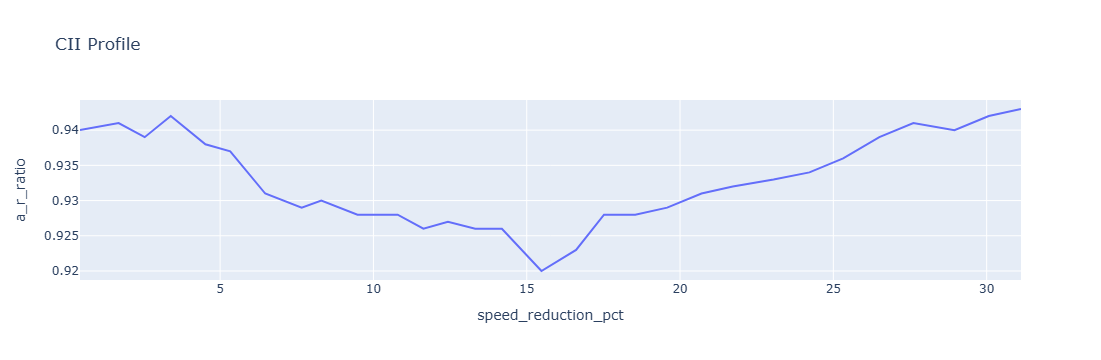

In [208]:
import plotly.express as px

fig = px.line(newdf, x="speed_reduction_pct", y="a_r_ratio" , title="CII Profile", color_discrete_map= {'A' : 'green', 'B' : 'lightgreen'} )
fig.update_yaxes(range=[0, 1.5]) 
fig.show()

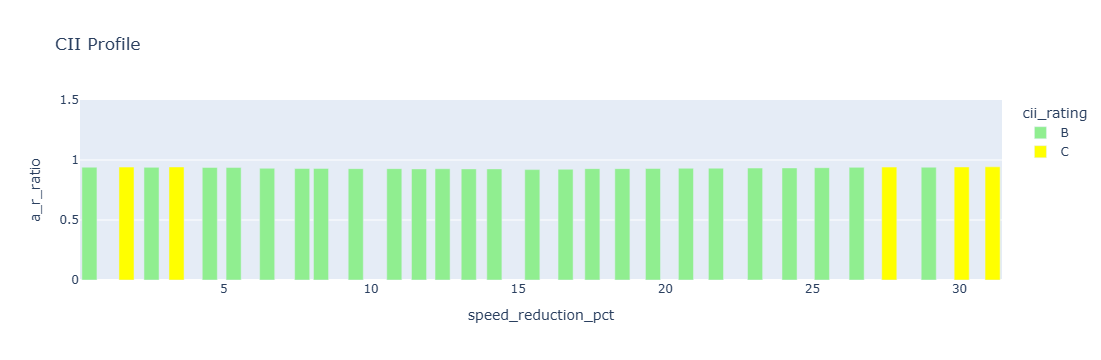

In [209]:
import plotly.express as px

fig = px.bar(newdf, x="speed_reduction_pct", 
             y="a_r_ratio", 
             color="cii_rating", 
             title="CII Profile", 
             color_discrete_map= {'A' : 'green', 'B' : 'lightgreen', 'C' : 'yellow',   'D' : 'orange'}
            )
fig.update_yaxes(range=[0, 1.5]) 
fig.show()

In [210]:
newdf.to_excel("Aditi_CII_Analysis_All_Data22.xlsx", index = False)